<a href="https://colab.research.google.com/github/Abrantes-Santos/brain-tumor-classification/blob/main/notebooks/brain_tumor_classification_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Classificação de Tumores Cerebrais em Imagens de MRI (PyTorch)

Este notebook executa o pipeline ponta a ponta do projeto **Brain Tumor Classification**, abrangendo:
* Clonagem do repositório modular e instalação de dependências.
* Extração automatizada do dataset oficial via API do Kaggle.
* Análise exploratória e visualização das amostras médicas.
* Treinamento da arquitetura convolucional customizada (`BrainTumorCNN`).
* Avaliação diagnóstica com matriz de confusão e métricas clínicas.

## 1. Configuração do Ambiente e Dependências
Clonagem do código-fonte modular hospedado no GitHub e instalação dos pacotes necessários, incluindo `kagglehub` para download automatizado.

In [18]:
!git clone https://github.com/Abrantes-Santos/brain-tumor-classification.git
%cd brain-tumor-classification
!pip install -r requirements.txt kagglehub

Cloning into 'brain-tumor-classification'...
remote: Enumerating objects: 116, done.
remote: Counting objects: 100% (116/116), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 116 (delta 54), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (116/116), 1.81 MiB | 5.10 MiB/s, done.
Resolving deltas: 100% (54/54), done.
/content/brain-tumor-classification/brain-tumor-classification/brain-tumor-classification/brain-tumor-classification


## 2. Ingestão Automatizada de Dados (Kaggle API)
Download da versão mais recente do dataset oficial (*Brain Tumor Classification (MRI)* por Sartaj Bhuvaji et al.) sem necessidade de chaves de autenticação manuais.

In [19]:
import os
import kagglehub

# Ingestão via kagglehub
kaggle_path = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")
data_path = os.path.join(kaggle_path, "Training")

print(f"[INFO] Dataset carregado com sucesso em:\n{data_path}")

Using Colab cache for faster access to the 'brain-tumor-classification-mri' dataset.
[INFO] Dataset carregado com sucesso em:
/kaggle/input/brain-tumor-classification-mri/Training


## 3. Inspeção Visual das Amostras de Ressonância (EDA)
Seleção aleatória de exames representativos de cada classe para validação da integridade dos arquivos e verificação dos padrões morfológicos das lesões.

[SUCESSO] Imagem salva em: reports/figures/dataset_samples.png


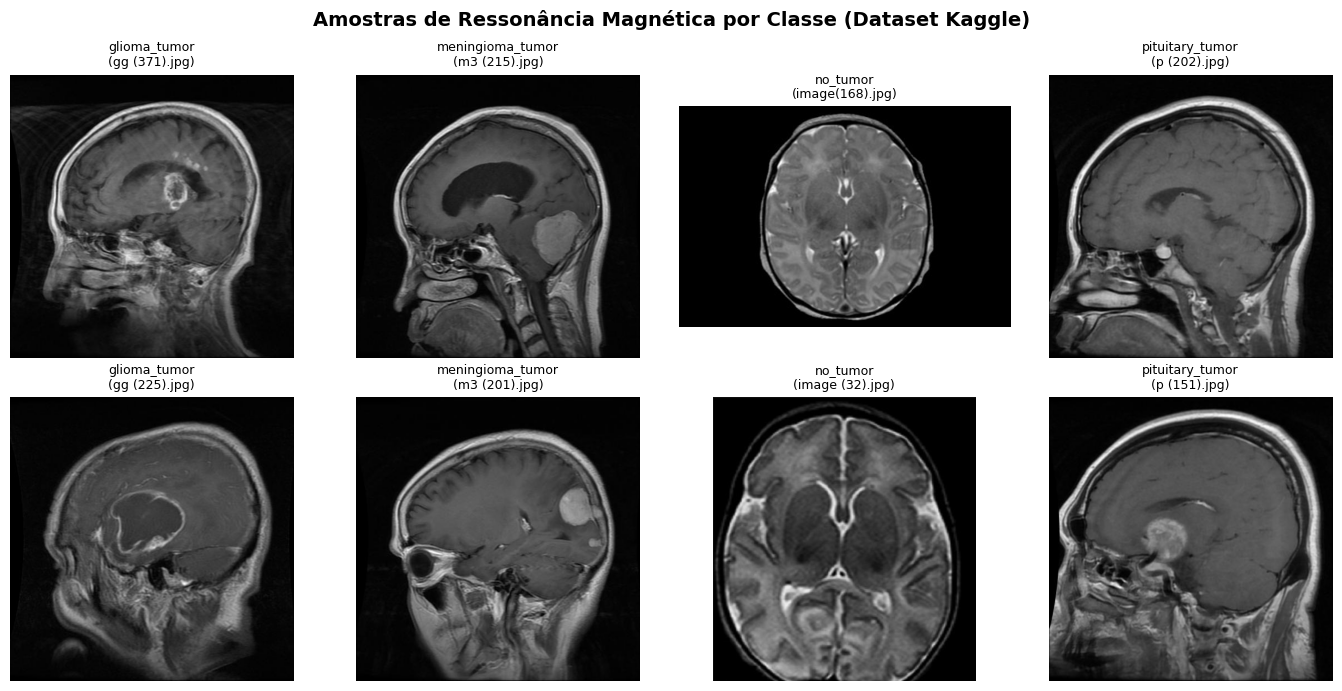

In [20]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

os.makedirs("reports/figures", exist_ok=True)

classes = ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"]
samples_per_class = 2

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Amostras de Ressonância Magnética por Classe (Dataset Kaggle)", fontsize=14, fontweight="bold")

col_idx = 0
for cls_name in classes:
    class_dir = os.path.join(data_path, cls_name)
    all_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    selected_files = random.sample(all_files, samples_per_class)

    for row_idx, file_name in enumerate(selected_files):
        img_path = os.path.join(class_dir, file_name)
        img = Image.open(img_path).convert("RGB")

        ax = axes[row_idx, col_idx]
        ax.imshow(img)
        ax.set_title(f"{cls_name}\n({file_name})", fontsize=9)
        ax.axis("off")

    col_idx += 1

plt.tight_layout()
save_path = "reports/figures/dataset_samples.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
print(f"[SUCESSO] Imagem salva em: {save_path}")
plt.show()

## 4. Distribuição das Classes (Treino vs. Validação)
Verificação do balanceamento do dataset considerando a partição estratificada de 80% para treino e 20% para validação (`seed=42`).

[INFO] Classes (4): ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
[INFO] Treino: 2296 amostras | Validação: 574 amostras
          Classe  Treino (80%)  Validação (20%)  Total Proporção Treino
    glioma_tumor           668              158    826           29.09%
meningioma_tumor           653              169    822           28.44%
        no_tumor           305               90    395           13.28%
 pituitary_tumor           670              157    827           29.18%


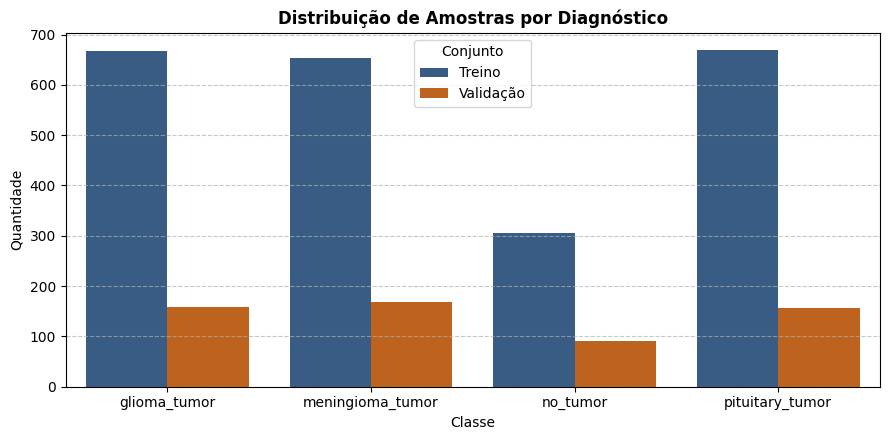

In [21]:
from collections import Counter
import pandas as pd
import seaborn as sns
from src.dataset import build_dataloaders

train_loader, val_loader, class_names = build_dataloaders(
    data_path=data_path,
    img_size=128,
    batch_size=64,
    train_split=0.8,
    seed=42
)

train_labels = [label for _, labels in train_loader for label in labels.tolist()]
val_labels = [label for _, labels in val_loader for label in labels.tolist()]

train_counts = Counter(train_labels)
val_counts = Counter(val_labels)

df_dist = pd.DataFrame([
    {
        "Classe": cls,
        "Treino (80%)": train_counts.get(i, 0),
        "Validação (20%)": val_counts.get(i, 0),
        "Total": train_counts.get(i, 0) + val_counts.get(i, 0),
        "Proporção Treino": f"{(train_counts.get(i, 0) / len(train_labels)) * 100:.2f}%"
    }
    for i, cls in enumerate(class_names)
])

print(df_dist.to_string(index=False))

df_plot = pd.DataFrame({
    "Classe": class_names * 2,
    "Quantidade": [train_counts.get(i, 0) for i in range(len(class_names))] +
                  [val_counts.get(i, 0) for i in range(len(class_names))],
    "Conjunto": ["Treino"] * len(class_names) + ["Validação"] * len(class_names)
})

plt.figure(figsize=(9, 4.5))
sns.barplot(data=df_plot, x="Classe", y="Quantidade", hue="Conjunto", palette=["#2b5c8f", "#d95f02"])
plt.title("Distribuição de Amostras por Diagnóstico", fontsize=12, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("reports/figures/data_distribution.png", dpi=200)
plt.show()

## 5. Treinamento da Rede Convolucional (`BrainTumorCNN`)
Execução do loop de treinamento e validação por 40 épocas com otimizador Adam ($\text{lr} = 0.001$), Cross-Entropy Loss e persistência automática do melhor checkpoint em `checkpoints/best_model.pth`.

In [22]:
!python -m src.train --data_path "{data_path}" --epochs 40 --batch_size 32

[INFO] Semente global configurada para: 42
[INFO] Dispositivo em uso: CUDA (Tesla T4)
[INFO] Classes (4): ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
[INFO] Treino: 2296 amostras | Validação: 574 amostras

[INFO] Iniciando treinamento por 40 épocas...
Época [01/40] | Train Loss: 2.7555 | Train Acc: 55.05% | Val Loss: 0.7179 | Val Acc: 69.34% [NOVO MELHOR]
Época [02/40] | Train Loss: 0.7813 | Train Acc: 65.46% | Val Loss: 0.6310 | Val Acc: 71.25% [NOVO MELHOR]
Época [03/40] | Train Loss: 0.7064 | Train Acc: 69.69% | Val Loss: 0.6073 | Val Acc: 75.26% [NOVO MELHOR]
Época [04/40] | Train Loss: 0.6879 | Train Acc: 70.60% | Val Loss: 0.6655 | Val Acc: 69.69% 
Época [05/40] | Train Loss: 0.6581 | Train Acc: 71.52% | Val Loss: 0.6204 | Val Acc: 75.44% [NOVO MELHOR]
Época [06/40] | Train Loss: 0.6531 | Train Acc: 72.30% | Val Loss: 0.5280 | Val Acc: 77.35% [NOVO MELHOR]
Época [07/40] | Train Loss: 0.6032 | Train Acc: 74.09% | Val Loss: 0.5290 | Val Acc: 77.87% [NOVO MEL

## 6. Avaliação Diagnóstica e Métricas Clínicas
Carregamento do melhor modelo salvo para geração da **Matriz de Confusão Normalizada**, relatório de **Precision, Recall e F1-Score** por patologia e visualização de inferências com intervalo de confiança.

[INFO] Dispositivo em uso: CUDA (Tesla T4)


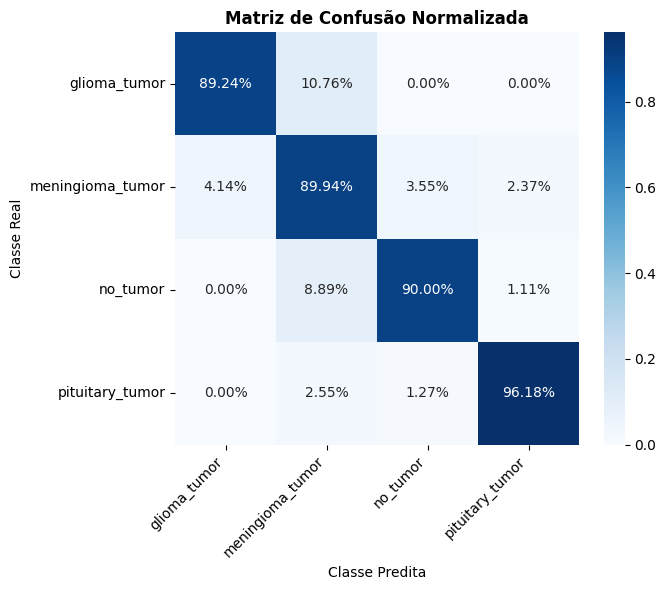


--- Relatório Clínico de Desempenho ---
                  precision    recall  f1-score   support

    glioma_tumor     0.9527    0.8924    0.9216       158
meningioma_tumor     0.8398    0.8994    0.8686       169
        no_tumor     0.9101    0.9000    0.9050        90
 pituitary_tumor     0.9679    0.9618    0.9649       157

        accuracy                         0.9146       574
       macro avg     0.9176    0.9134    0.9150       574
    weighted avg     0.9169    0.9146    0.9152       574



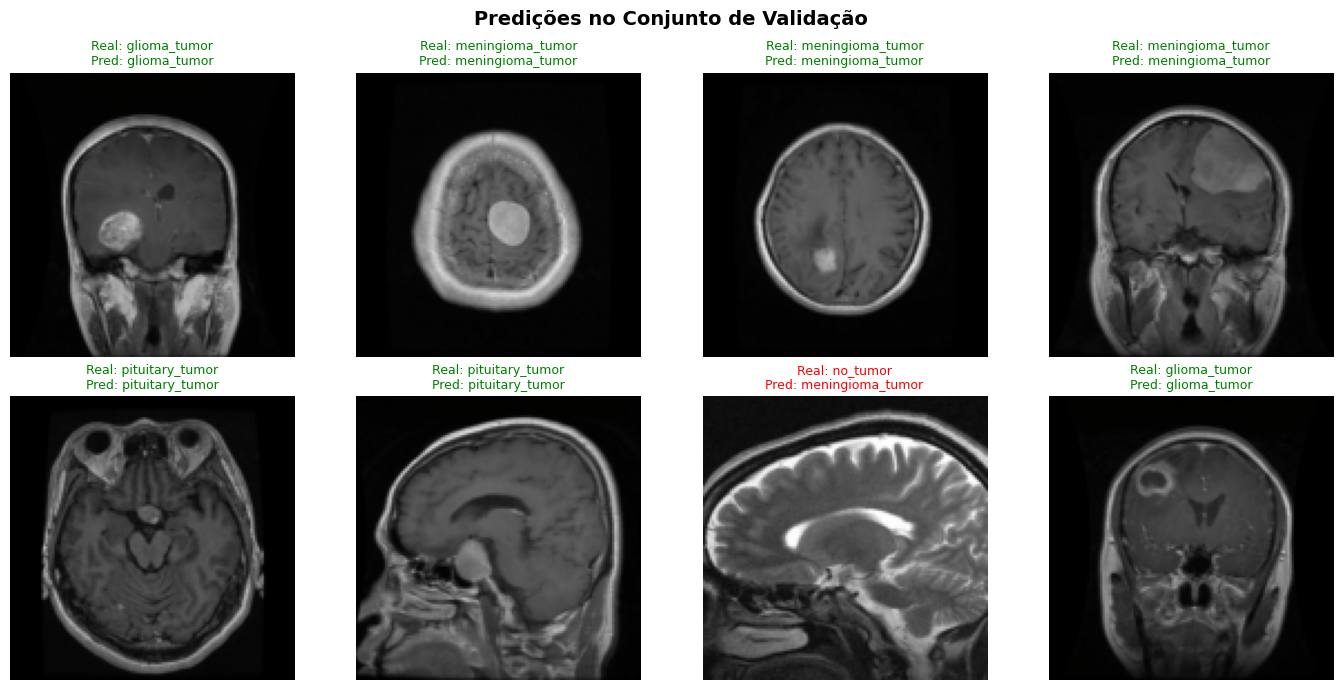

In [23]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from src.predict import load_checkpoint
from src.utils import denormalize, get_device

device = get_device()
checkpoint_path = "checkpoints/best_model.pth"
model, class_names = load_checkpoint(checkpoint_path, device)

y_true, y_pred, raw_images = [], [], []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images.to(device))
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        if len(raw_images) < 8:
            raw_images.extend(images.cpu())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Matriz de Confusão
cm = confusion_matrix(y_true, y_pred, normalize='true')
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de Confusão Normalizada", fontsize=12, fontweight="bold")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("reports/figures/confusion_matrix.png", dpi=200)
plt.show()

# Relatório de Classificação
print("\n--- Relatório Clínico de Desempenho ---")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Amostras de Inferência
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Predições no Conjunto de Validação", fontsize=14, fontweight="bold")

for i in range(8):
    r, c = i // 4, i % 4
    ax = axes[r, c]
    img = denormalize(raw_images[i])
    true_cls = class_names[y_true[i]]
    pred_cls = class_names[y_pred[i]]

    color = "green" if true_cls == pred_cls else "red"
    ax.imshow(img)
    ax.set_title(f"Real: {true_cls}\nPred: {pred_cls}", color=color, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("reports/figures/sample_predictions.png", dpi=200)
plt.show()